In [29]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

In [30]:

# Load the CSV file
df = pd.read_csv('/home/mimic-iv_subjectids_tsids.csv', names=["subject_id", "itemid", "c"])
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (9381560, 3)
Columns: ['subject_id', 'itemid', 'c']


,subject_id,itemid,c
0,10253349,220277,7685
1,10253349,220045,7682
2,10253349,229381,7676
3,10253349,220210,7361
4,11488234,224685,5929


In [31]:
df.groupby("itemid").agg({"c": "sum", "subject_id": "count"}).sort_values("c", ascending=False)

,c,subject_id
itemid,,
220045,8752069,65365
220210,8636655,65302
220277,8567015,65304
220179,5378740,64703
220180,5377689,64702
...,...,...
224727,2,2
230145,2,2
225657,1,1


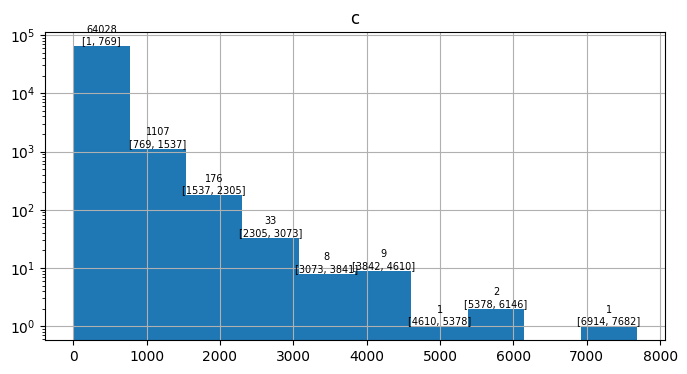

In [38]:
def filter_and_plot(df: pd.DataFrame, itemid: int = 220045, bins = 10):
    fig, axs = plt.subplots(1, 1, figsize=(8, 4))
    if itemid is not None:
        df = df[df["itemid"] == itemid]
    df.hist(column="c", bins=bins, ax=axs)
    axs.set_yscale("log")
    for bar in axs.patches:
        if bar.get_height() == 0:
            continue
        x_left = bar.get_x()
        x_right = bar.get_x() + bar.get_width()
        axs.text(
            x_left + bar.get_width() / 2,
            bar.get_height(),
            f"{int(bar.get_height())}\n[{x_left:.0f}, {x_right:.0f}]",
            ha="center", va="bottom", fontsize=7
        )

filter_and_plot(df)

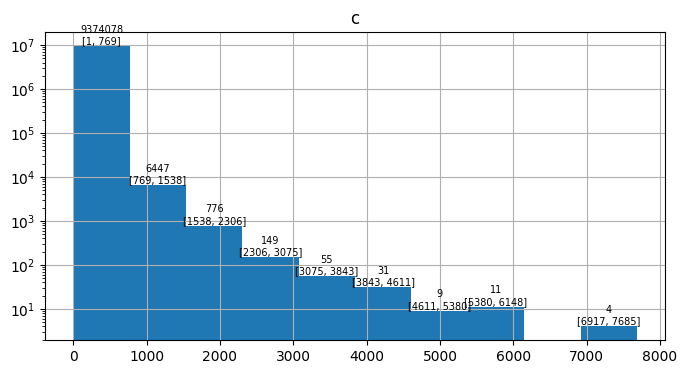

In [33]:
filter_and_plot(df, itemid = 220277)

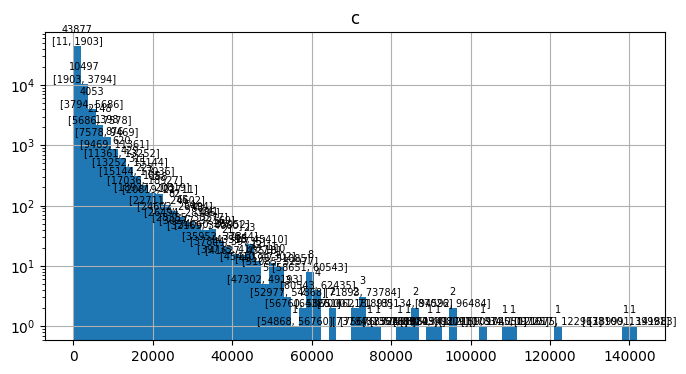

In [37]:
filter_and_plot(df.groupby("subject_id").agg({"c": "sum"}).sort_values("c", ascending=False), itemid = None, bins=75)